# Patrones Invisibles: Incertidumbre, Segmentación y Perfiles de Movilidad para UrbanMove
**Hecho por :** Sergio Moreno, Camilo Ocampo, Alejandro Rios y Sebastián Toro

## Fase 1: Librerias

In [1]:
# Librerias principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias de modelos
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from scipy.special import logsumexp
from sklearn.metrics import mutual_info_score
from sklearn.cluster import kmeans_plusplus
from scipy.stats import ks_2samp


# Configuracion general
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("compute.use_numexpr", False)
pd.set_option("compute.use_bottleneck", False)
sns.set_style("whitegrid")
SEMILLA = 42

## Fase 2: Carga y observación

Cargamos el histórico completo de viajes para conocer su tamaño y estructura.

In [2]:
# Carga del dataset
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982,40.768,-73.965,40.766,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980,40.739,-73.999,40.731,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979,40.764,-74.005,40.710,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010,40.720,-74.012,40.707,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973,40.793,-73.973,40.783,N,435


Verificamos tipos de datos, valores nulos e IDs duplicados antes de cualquier análisis.

In [3]:
# Tipos de datos y nulos
df.info()
print(df.isna().sum())
print(df["id"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


0


 Revisamos los valores mínimos y máximos

In [4]:
# Estadisticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1458644.000,1.535,0.499,1.000,1.000,2.000,2.000,2.000
passenger_count,1458644.000,1.665,1.314,0.000,1.000,1.000,2.000,9.000
pickup_longitude,1458644.000,-73.973,0.071,-121.933,-73.992,-73.982,-73.967,-61.336
pickup_latitude,1458644.000,40.751,0.033,34.360,40.737,40.754,40.768,51.881
dropoff_longitude,1458644.000,-73.973,0.071,-121.933,-73.991,-73.980,-73.963,-61.336
dropoff_latitude,1458644.000,40.752,0.036,32.181,40.736,40.755,40.770,43.921
trip_duration,1458644.000,959.492,5237.432,1.000,397.000,662.000,1075.000,3526282.000


Revisión de distribución de pasajeros

In [5]:
# Revision de pasajeros y bandera
print(df["passenger_count"].value_counts().sort_index())
print(df["store_and_fwd_flag"].value_counts())

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64
store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64


### Hallazgos de la observación

- El dataset tiene 1.458.644 viajes y 11 variables, entre enero y junio de 2016.
- No hay valores nulos ni IDs duplicados.
- Sin embargo, hay registros imposibles:
  - Una duración máxima de 979 horas, un taxímetro que nunca se apagó.
  - Coordenadas con longitud de 121, que corresponde a California, no a Nueva York.
  - 60 viajes con 0 pasajeros y 5 con más de 6.
- El 99% de los viajes tiene la bandera store_and_fwd_flag en N, así que aporta poca información y no la usaremos.

Conclusión: el dataset está completo pero no limpio. En la siguiente fase aplicamos reglas de limpieza justificadas.

## Fase 3: Limpieza

Calculamos la distancia real entre recogida y destino con la fórmula de Haversine, que considera la curvatura de la Tierra. La necesitamos para detectar velocidades imposibles.

In [6]:
# Distancia haversine en km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distancia_km"] = haversine(df["pickup_latitude"], df["pickup_longitude"],
                               df["dropoff_latitude"], df["dropoff_longitude"])

# Velocidad promedio en km por hora
df["velocidad_kmh"] = df["distancia_km"] / (df["trip_duration"] / 3600)
df[["distancia_km", "velocidad_kmh"]].describe().T

,count,mean,std,min,25%,50%,75%,max
distancia_km,1458644.000,3.441,4.297,0.000,1.232,2.094,3.875,1240.909
velocidad_kmh,1458644.000,14.423,14.978,0.000,9.121,12.792,17.845,9274.837


Definimos cinco reglas de limpieza. Cada una elimina registros físicamente imposibles o errores de registro, no viajes simplemente raros.

In [7]:
# Limites geograficos de Nueva York
LON_MIN, LON_MAX = -74.3, -73.7
LAT_MIN, LAT_MAX = 40.5, 41.0

# Reglas de limpieza
reglas = {
    "fuera_de_nyc": ~(df["pickup_longitude"].between(LON_MIN, LON_MAX) &
                      df["pickup_latitude"].between(LAT_MIN, LAT_MAX) &
                      df["dropoff_longitude"].between(LON_MIN, LON_MAX) &
                      df["dropoff_latitude"].between(LAT_MIN, LAT_MAX)),
    "duracion_invalida": ~df["trip_duration"].between(60, 6 * 3600),
    "pasajeros_invalidos": ~df["passenger_count"].between(1, 6),
    "distancia_casi_cero": df["distancia_km"] < 0.05,
    "velocidad_imposible": ~df["velocidad_kmh"].between(1, 100),
}

# Conteo por regla
resumen = pd.DataFrame({"registros": {k: v.sum() for k, v in reglas.items()}})
resumen["porcentaje"] = resumen["registros"] / len(df) * 100
resumen

,registros,porcentaje
fuera_de_nyc,998,0.068
duracion_invalida,10656,0.731
pasajeros_invalidos,65,0.004
distancia_casi_cero,11329,0.777
velocidad_imposible,13415,0.920


Aplicamos todas las reglas al mismo tiempo. Un viaje se elimina si incumple al menos una.

In [8]:
# Aplicar todas las reglas
mascara_error = np.logical_or.reduce(list(reglas.values()))
df_limpio = df[~mascara_error].copy()

print(f"Registros originales: {len(df):,}")
print(f"Registros eliminados: {mascara_error.sum():,}")
print(f"Porcentaje eliminado: {mascara_error.mean() * 100:.2f}%")
print(f"Registros limpios: {len(df_limpio):,}")

Registros originales: 1,458,644
Registros eliminados: 19,780
Porcentaje eliminado: 1.36%
Registros limpios: 1,438,864


In [9]:
# Verificacion despues de limpiar
df_limpio[["trip_duration", "distancia_km", "velocidad_kmh", "passenger_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
trip_duration,1438864.000,840.543,655.926,60.000,401.000,665.000,1075.000,21411.000
distancia_km,1438864.000,3.460,3.888,0.050,1.257,2.118,3.906,47.765
velocidad_kmh,1438864.000,14.473,7.598,1.000,9.230,12.857,17.879,99.532
passenger_count,1438864.000,1.665,1.314,1.000,1.000,1.000,2.000,6.000


### Hallazgos de la limpieza

- Se eliminaron 19.780 registros, apenas el 1,36% del total.
- Quedan 1.438.864 viajes válidos.
- Las reglas se traslapan: la suma por regla es mayor al total eliminado porque un mismo viaje suele tener varios errores.
- Después de limpiar, la duración máxima baja de 979 horas a unas 6 horas y la velocidad máxima de 9.274 km/h a menos de 100 km/h.

Decisión clave: no eliminamos viajes raros pero reales, como los viajes largos al aeropuerto. Esos los dejamos para que DBSCAN los detecte como ruido en la fase de clustering.

## Fase 4: Variables derivadas

Extraemos variables temporales de la fecha de recogida. Son la base para comparar la demanda entre momentos del día y tipos de día.

In [10]:
# Convertir fecha a formato datetime
df_limpio["pickup_datetime"] = pd.to_datetime(df_limpio["pickup_datetime"])

# Variables de tiempo
df_limpio["hora"] = df_limpio["pickup_datetime"].dt.hour
df_limpio["dia_semana"] = df_limpio["pickup_datetime"].dt.dayofweek
df_limpio["mes"] = df_limpio["pickup_datetime"].dt.month
df_limpio["fin_de_semana"] = (df_limpio["dia_semana"] >= 5).astype(int)

df_limpio[["pickup_datetime", "hora", "dia_semana", "mes", "fin_de_semana"]].head()

,pickup_datetime,hora,dia_semana,mes,fin_de_semana
0,2016-03-14 17:24:55,17,0,3,0
1,2016-06-12 00:43:35,0,6,6,1
2,2016-01-19 11:35:24,11,1,1,0
3,2016-04-06 19:32:31,19,2,4,0
4,2016-03-26 13:30:55,13,5,3,1


Agrupamos las 24 horas en cinco franjas con sentido operativo para UrbanMove.

In [11]:
# Franjas horarias
def asignar_franja(h):
    if h < 6:
        return "madrugada"
    elif h < 10:
        return "pico_manana"
    elif h < 16:
        return "valle_dia"
    elif h < 20:
        return "pico_tarde"
    else:
        return "noche"

df_limpio["franja"] = df_limpio["hora"].apply(asignar_franja)
df_limpio["franja"].value_counts(normalize=True)

franja
valle_dia     0.290
pico_tarde    0.221
noche         0.219
pico_manana   0.153
madrugada     0.117
Name: proportion, dtype: float64

Dividimos la ciudad en una cuadrícula de celdas de 0.01 grados, aproximadamente 1 km por lado. Cada viaje recibe una zona de origen y una de destino.

In [12]:
# Cuadricula geografica
TAM_CELDA = 0.01

def asignar_celda(lat, lon):
    fila = ((lat - LAT_MIN) // TAM_CELDA).astype(int)
    col = ((lon - LON_MIN) // TAM_CELDA).astype(int)
    return "Z" + fila.astype(str) + "_" + col.astype(str)

df_limpio["celda_origen"] = asignar_celda(df_limpio["pickup_latitude"], df_limpio["pickup_longitude"])
df_limpio["celda_destino"] = asignar_celda(df_limpio["dropoff_latitude"], df_limpio["dropoff_longitude"])

print(df_limpio["celda_origen"].nunique())

653


Agrupamos las celdas con muy pocos viajes en una categoría OTRA para que las probabilidades por zona sean confiables.

In [13]:
# Zonas frecuentes con al menos medio por ciento de viajes
UMBRAL = 0.005
frec = df_limpio["celda_origen"].value_counts(normalize=True)
zonas_frecuentes = frec[frec >= UMBRAL].index

df_limpio["zona_origen"] = df_limpio["celda_origen"].where(
    df_limpio["celda_origen"].isin(zonas_frecuentes), "OTRA")
df_limpio["zona_destino"] = df_limpio["celda_destino"].where(
    df_limpio["celda_destino"].isin(zonas_frecuentes), "OTRA")

print(f"Celdas totales: {df_limpio['celda_origen'].nunique()}")
print(f"Zonas frecuentes: {len(zonas_frecuentes)}")
print(f"Viajes en OTRA origen: {(df_limpio['zona_origen'] == 'OTRA').mean() * 100:.2f}%")
print(f"Viajes en OTRA destino: {(df_limpio['zona_destino'] == 'OTRA').mean() * 100:.2f}%")

Celdas totales: 653
Zonas frecuentes: 42
Viajes en OTRA origen: 6.87%
Viajes en OTRA destino: 15.55%


Revisamos cómo cambian duración, distancia y velocidad según la franja horaria.

In [14]:
# Resumen por franja
df_limpio.groupby("franja").agg(
    viajes=("id", "count"),
    duracion_media_min=("trip_duration", lambda x: x.mean() / 60),
    distancia_media_km=("distancia_km", "mean"),
    velocidad_media_kmh=("velocidad_kmh", "mean"),
).round(2)

,viajes,duracion_media_min,distancia_media_km,velocidad_media_kmh
franja,,,,
madrugada,168407,12.400,4.220,19.420
noche,314550,13.210,3.700,15.980
pico_manana,220617,13.290,3.270,14.750
pico_tarde,317562,14.700,3.250,12.880
valle_dia,417728,15.120,3.230,12.410


### Hallazgos de las variables derivadas

- El 28,5% de los viajes ocurre en fin de semana.
- La franja con más viajes es valle día, de 10 a 15, con el 29%.
- Las 42 zonas frecuentes concentran el 93% de las recogidas. La demanda está muy concentrada geográficamente.
- El 15,6% de los destinos cae en OTRA, más del doble que en origen con 6,9%. La gente se recoge en el centro pero viaja a zonas más dispersas.
- La madrugada tiene los viajes más largos, 4,22 km, y más rápidos, 19,4 km/h, porque no hay tráfico.
- El valle día es la franja más lenta, 12,4 km/h, incluso más que los picos. Lo mismo se ve en el pico de la tarde, con 12,9 km/h.

## Fase 5: Muestreo

Trabajar con 1,4 millones de viajes hace lentos los algoritmos, sobre todo DBSCAN y EM. Tomamos una muestra aleatoria de 40.000 viajes estratificada por mes, con semilla fija para que el resultado sea reproducible.

In [15]:
# Muestra estratificada por mes
TAM_MUESTRA = 40000
fraccion = TAM_MUESTRA / len(df_limpio)

muestra = (df_limpio.groupby("mes", group_keys=False)
           .sample(frac=fraccion, random_state=SEMILLA)
           .reset_index(drop=True))

print(f"Tamaño de la muestra: {len(muestra):,}")
print(f"Fracción muestreada: {fraccion * 100:.2f}%")

Tamaño de la muestra: 40,000
Fracción muestreada: 2.78%


Verificamos que la muestra conserve la distribución por mes y por franja horaria de la población limpia.

In [16]:
# Comparacion por mes
comp_mes = pd.DataFrame({
    "poblacion": df_limpio["mes"].value_counts(normalize=True).sort_index() * 100,
    "muestra": muestra["mes"].value_counts(normalize=True).sort_index() * 100,
}).round(2)
comp_mes

,poblacion,muestra
mes,,
1,15.740,15.740
2,16.340,16.340
3,17.570,17.580
4,17.250,17.250
5,17.030,17.040
6,16.050,16.060


Aplicamos la prueba de Kolmogorov Smirnov para confirmar estadísticamente que las variables numéricas de la muestra y la población vienen de la misma distribución.

In [17]:

# Prueba KS por variable
variables = ["trip_duration", "distancia_km", "velocidad_kmh", "hora"]
resultados_ks = []
for v in variables:
    estadistico, p_valor = ks_2samp(df_limpio[v], muestra[v])
    resultados_ks.append({
        "variable": v,
        "media_poblacion": df_limpio[v].mean(),
        "media_muestra": muestra[v].mean(),
        "estadistico_ks": estadistico,
        "p_valor": p_valor,
    })

pd.DataFrame(resultados_ks).round(4)

,variable,media_poblacion,media_muestra,estadistico_ks,p_valor
0,trip_duration,840.543,842.131,0.002,0.988
1,distancia_km,3.460,3.470,0.003,0.944
2,velocidad_kmh,14.473,14.488,0.005,0.274
3,hora,13.614,13.644,0.004,0.422


### Hallazgos del muestreo

- La muestra de 40.000 viajes representa el 2,78% de la población limpia.
- La proporción por mes es prácticamente idéntica, con diferencias menores a 0,01 puntos.
- Las franjas horarias se conservan con diferencias menores a 0,3 puntos.
- En la prueba KS ninguna variable muestra diferencia significativa. Todos los p valores son mayores a 0,05, con el más bajo en 0,274.

Conclusión: la muestra es representativa. Los resultados de las siguientes fases se pueden generalizar a la operación completa de UrbanMove.

## Fase 6: Teoría de la información (parte 1)

En esta fase cuantificamos qué tan predecible es la demanda de UrbanMove. Trabajamos en bits, usando logaritmo en base 2, y estimamos las probabilidades de cada zona a partir de las frecuencias de la muestra.

In [18]:
# Categorias base
ZONAS = sorted(muestra["zona_origen"].unique())
ORDEN_FRANJAS = ["madrugada", "pico_manana", "valle_dia", "pico_tarde", "noche"]

# Nombres aproximados de zonas clave
NOMBRES = {
    "Z25_32": "Midtown East", "Z25_31": "Times Square", "Z24_31": "Murray Hill",
    "Z26_31": "Midtown West", "Z22_31": "East Village", "Z22_30": "SoHo",
    "Z23_29": "West Village", "Z24_29": "Chelsea", "Z27_33": "Upper East Side",
    "Z26_33": "Lenox Hill", "Z28_34": "Upper East Norte",
    "Z14_51": "Aeropuerto JFK", "Z27_42": "LaGuardia", "Z26_43": "LaGuardia 2",
    "OTRA": "Otras zonas",
}

# Distribucion de probabilidad con suavizado de Laplace
def distribucion(serie, categorias, alfa=1):
    conteos = serie.value_counts().reindex(categorias, fill_value=0)
    return (conteos + alfa) / (conteos.sum() + alfa * len(categorias))

p_zona = distribucion(muestra["zona_origen"], ZONAS)
print(f"Número de zonas: {len(ZONAS)}")
print(f"Suma de probabilidades: {p_zona.sum():.4f}")
p_zona.sort_values(ascending=False).head(5).rename(index=NOMBRES)

Número de zonas: 43
Suma de probabilidades: 1.0000


zona_origen
Otras zonas    0.070
Midtown East   0.062
Murray Hill    0.048
Midtown West   0.048
Times Square   0.045
Name: count, dtype: float64

Calculamos la entropía de Shannon de la distribución de recogidas por zona. Una entropía alta significa demanda dispersa y difícil de anticipar. Una baja significa demanda concentrada en pocas zonas.

In [19]:
# Entropia de Shannon en bits
def entropia(p):
    p = np.asarray(p)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

H_total = entropia(p_zona)
H_max = np.log2(len(ZONAS))

print(f"Entropía total: {H_total:.3f} bits")
print(f"Entropía máxima posible: {H_max:.3f} bits")
print(f"Eficiencia: {H_total / H_max * 100:.1f}%")
print(f"Zonas efectivas: {2 ** H_total:.1f} de {len(ZONAS)}")

Entropía total: 5.103 bits
Entropía máxima posible: 5.426 bits
Eficiencia: 94.0%
Zonas efectivas: 34.4 de 43


Comparamos la entropía por franja horaria para identificar en qué momento del día la demanda es más predecible.

In [20]:
# Entropia por franja
filas = []
for f in ORDEN_FRANJAS:
    p = distribucion(muestra.loc[muestra["franja"] == f, "zona_origen"], ZONAS)
    H = entropia(p)
    filas.append({
        "franja": f,
        "viajes": (muestra["franja"] == f).sum(),
        "entropia_bits": H,
        "eficiencia_pct": H / H_max * 100,
        "zonas_efectivas": 2 ** H,
        "top4_zonas_pct": p.sort_values(ascending=False).head(4).sum() * 100,
    })

tabla_entropia = pd.DataFrame(filas).round(3)
tabla_entropia

,franja,viajes,entropia_bits,eficiencia_pct,zonas_efectivas,top4_zonas_pct
0,madrugada,4601,4.852,89.415,28.877,29.177
1,pico_manana,6091,5.076,93.548,33.735,24.389
2,valle_dia,11725,5.100,93.991,34.302,22.238
3,pico_tarde,8780,5.103,94.040,34.365,22.430
4,noche,8803,5.035,92.783,32.778,24.384


In [21]:
# Entropia laboral versus fin de semana
p_lab = distribucion(muestra.loc[muestra["fin_de_semana"] == 0, "zona_origen"], ZONAS)
p_fds = distribucion(muestra.loc[muestra["fin_de_semana"] == 1, "zona_origen"], ZONAS)

print(f"Entropía laboral: {entropia(p_lab):.3f} bits")
print(f"Entropía fin de semana: {entropia(p_fds):.3f} bits")

Entropía laboral: 5.093 bits
Entropía fin de semana: 5.091 bits


La entropía mide cuánta concentración hay, pero no dónde. Usamos la divergencia KL para medir qué tan distinta es la distribución de zonas entre días laborales y fin de semana.

In [22]:
# Divergencia KL en bits
def kl(p, q):
    p, q = np.asarray(p), np.asarray(q)
    return np.sum(p * np.log2(p / q))

print(f"KL laboral respecto a fin de semana: {kl(p_lab, p_fds):.4f} bits")
print(f"KL fin de semana respecto a laboral: {kl(p_fds, p_lab):.4f} bits")

KL laboral respecto a fin de semana: 0.0514 bits
KL fin de semana respecto a laboral: 0.0546 bits


In [23]:
# Zonas que mas cambian en fin de semana
cambio = ((p_fds - p_lab) * 100).sort_values()
cambio_zonas = pd.concat([cambio.head(4), cambio.tail(4)]).rename(index=NOMBRES)
cambio_zonas.round(2).to_frame("cambio_puntos_pct")

,cambio_puntos_pct
zona_origen,
Midtown East,-2.400
Upper East Side,-0.760
Upper East Norte,-0.730
Lenox Hill,-0.700
West Village,1.360
SoHo,1.530
Otras zonas,1.790
East Village,1.880


Calculamos la matriz de divergencia KL entre todas las franjas horarias para identificar qué momentos del día tienen patrones de demanda más parecidos o más distintos.

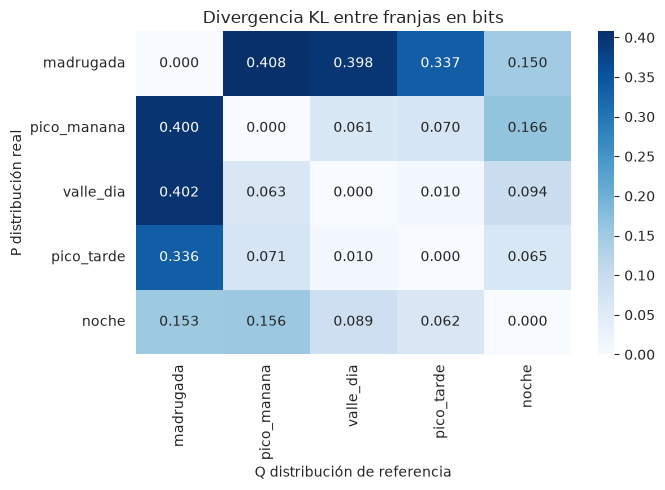

In [24]:
# Matriz KL entre franjas
dists = {f: distribucion(muestra.loc[muestra["franja"] == f, "zona_origen"], ZONAS)
         for f in ORDEN_FRANJAS}

matriz_kl = pd.DataFrame(
    [[kl(dists[a], dists[b]) for b in ORDEN_FRANJAS] for a in ORDEN_FRANJAS],
    index=ORDEN_FRANJAS, columns=ORDEN_FRANJAS)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_kl, annot=True, fmt=".3f", cmap="Blues")
plt.title("Divergencia KL entre franjas en bits")
plt.xlabel("Q distribución de referencia")
plt.ylabel("P distribución real")
plt.tight_layout()
plt.show()

Verificamos la relación entre entropía cruzada, entropía y divergencia KL con nuestros propios datos.

In [25]:
# Entropia cruzada en bits
def entropia_cruzada(p, q):
    p, q = np.asarray(p), np.asarray(q)
    return -np.sum(p * np.log2(q))

H_lab = entropia(p_lab)
CE = entropia_cruzada(p_lab, p_fds)
KL_lf = kl(p_lab, p_fds)

print(f"Entropía cruzada laboral con modelo fin de semana: {CE:.4f} bits")
print(f"Entropía laboral más KL: {H_lab + KL_lf:.4f} bits")
print(f"Diferencia: {abs(CE - (H_lab + KL_lf)):.2e}")

Entropía cruzada laboral con modelo fin de semana: 5.1444 bits
Entropía laboral más KL: 5.1444 bits
Diferencia: 1.78e-15


### Hallazgos de teoría de la información parte 1

- La demanda total tiene una entropía de 5,10 bits sobre un máximo de 5,43. Equivale a 34 zonas efectivas de 43, así que la demanda está bastante dispersa en general.
- La madrugada es la franja más predecible: 4,85 bits, 28,9 zonas efectivas, y las 4 zonas principales concentran el 29% de los viajes.
- Días laborales y fin de semana tienen la misma entropía, 5,09 bits, pero una KL de 0,051 bits. El nivel de concentración es igual, pero las zonas cambian: en fin de semana la demanda se mueve de Midtown East, con 2,4 puntos menos, hacia East Village, SoHo y West Village. Es el paso de zonas de oficina a zonas de vida nocturna.
- La KL es asimétrica: 0,0514 contra 0,0546 bits.
- Madrugada y pico mañana son los patrones más distintos del día, con KL de 0,408 bits. Valle día y pico tarde son casi idénticos, con 0,0096 bits: UrbanMove podría usar la misma distribución de flota en ambos.
- Se verificó que la entropía cruzada es igual a la entropía más la KL, con 5,144 bits.

## Fase 6: Teoría de la información (parte 2)

Medimos cuánta información aporta cada variable sobre la zona de destino. Usamos la entropía condicional, que es la incertidumbre que queda sobre el destino cuando ya conocemos otra variable, y la información mutua, que es cuánta incertidumbre se elimina.

In [26]:
# Entropia empirica y condicional
def entropia_empirica(serie):
    return entropia(serie.value_counts(normalize=True))

def entropia_condicional(y, x):
    px = x.value_counts(normalize=True)
    return sum(px[k] * entropia_empirica(y[x == k]) for k in px.index)

# Informacion mutua con el destino
y = muestra["zona_destino"]
H_y = entropia_empirica(y)

filas = []
for var in ["fin_de_semana", "franja", "hora", "zona_origen"]:
    H_cond = entropia_condicional(y, muestra[var])
    filas.append({
        "variable": var,
        "H_destino": H_y,
        "H_destino_dado_var": H_cond,
        "info_mutua_bits": H_y - H_cond,
        "reduccion_pct": (H_y - H_cond) / H_y * 100,
    })

tabla_im = pd.DataFrame(filas).round(4)
tabla_im

,variable,H_destino,H_destino_dado_var,info_mutua_bits,reduccion_pct
0,fin_de_semana,4.936,4.929,0.008,0.155
1,franja,4.936,4.868,0.068,1.384
2,hora,4.936,4.839,0.098,1.976
3,zona_origen,4.936,4.586,0.351,7.103


Validamos nuestra información mutua contra sklearn y aplicamos una prueba de permutación. Si mezclamos la hora al azar, la relación real se destruye, y así sabemos cuánta información mutua aparece solo por azar con 40.000 viajes.

In [27]:
# Validacion con sklearn en bits
im_sklearn = mutual_info_score(muestra["hora"], y) / np.log(2)
print(f"Información mutua hora con sklearn: {im_sklearn:.4f} bits")

# Prueba de permutacion
rng = np.random.default_rng(SEMILLA)
im_azar = [mutual_info_score(rng.permutation(muestra["hora"].values), y) / np.log(2)
           for _ in range(100)]
im_real = tabla_im.loc[tabla_im["variable"] == "hora", "info_mutua_bits"].values[0]

print(f"Información mutua real: {im_real:.4f} bits")
print(f"Promedio al azar: {np.mean(im_azar):.4f} bits")
print(f"Máximo al azar: {np.max(im_azar):.4f} bits")
print(f"La real es {im_real / np.mean(im_azar):.1f} veces la del azar")

Información mutua hora con sklearn: 0.0975 bits


Información mutua real: 0.0975 bits
Promedio al azar: 0.0176 bits
Máximo al azar: 0.0199 bits
La real es 5.5 veces la del azar


Verificamos la desigualdad de Jensen con nuestros datos. Jensen dice que para una función cóncava como el logaritmo, el promedio del logaritmo es menor o igual al logaritmo del promedio. De ella se derivan dos propiedades que usamos arriba: la KL nunca es negativa y la entropía nunca supera log2 de K.

In [28]:
# Consecuencia 1 KL no negativa
kls = [kl(dists[a], dists[b]) for a in ORDEN_FRANJAS for b in ORDEN_FRANJAS if a != b]
print(f"Pares de franjas evaluados: {len(kls)}")
print(f"KL mínima: {min(kls):.4f} bits, todas mayores que cero: {all(k > 0 for k in kls)}")

# Consecuencia 2 entropia acotada
print(f"Todas las entropías menores a log2 de 43: {all(entropia(dists[f]) <= H_max for f in ORDEN_FRANJAS)}")

# Jensen directo sobre la duracion
dur_min = muestra["trip_duration"] / 60
media_log = np.mean(np.log2(dur_min))
log_media = np.log2(dur_min.mean())

print(f"Promedio del log2 de la duración: {media_log:.4f}")
print(f"Log2 del promedio de la duración: {log_media:.4f}")
print(f"Media geométrica: {2 ** media_log:.2f} min")
print(f"Media aritmética: {dur_min.mean():.2f} min")
print(f"Mediana: {dur_min.median():.2f} min")

Pares de franjas evaluados: 20
KL mínima: 0.0096 bits, todas mayores que cero: True
Todas las entropías menores a log2 de 43: True
Promedio del log2 de la duración: 3.4410
Log2 del promedio de la duración: 3.8110
Media geométrica: 10.86 min
Media aritmética: 14.04 min
Mediana: 11.08 min


Aplicamos el truco log sum exp a un problema real: dado un lote de 500 viajes, identificar de qué franja horaria provienen usando solo sus zonas de origen. Multiplicar 500 probabilidades da un número tan pequeño que el computador lo redondea a cero, así que trabajamos en escala logarítmica.

In [29]:
# Log probabilidades por franja
log_p = pd.DataFrame({f: np.log(dists[f]) for f in ORDEN_FRANJAS})
log_prior = np.log(muestra["franja"].value_counts(normalize=True).reindex(ORDEN_FRANJAS))

# Clasificar lotes de 500 viajes
N_LOTE = 500
filas = []
for f_real in ORDEN_FRANJAS:
    lote = muestra[muestra["franja"] == f_real].sample(N_LOTE, random_state=SEMILLA)
    log_ver = log_p.loc[lote["zona_origen"]].sum(axis=0) + log_prior

    # Calculo ingenuo
    with np.errstate(invalid="ignore"):
        ingenuo = np.exp(log_ver) / np.exp(log_ver).sum()

    # Calculo estable
    posterior = np.exp(log_ver - logsumexp(log_ver))

    filas.append({
        "franja_real": f_real,
        "log_verosimilitud_max": log_ver.max(),
        "suma_ingenua": np.exp(log_ver).sum(),
        "posterior_ingenuo": ingenuo[f_real],
        "franja_estimada": posterior.idxmax(),
        "prob_franja_real": posterior[f_real],
    })

tabla_lse = pd.DataFrame(filas).round(4)
tabla_lse

,franja_real,log_verosimilitud_max,suma_ingenua,posterior_ingenuo,franja_estimada,prob_franja_real
0,madrugada,-1703.401,0.000,NaN,madrugada,1.000
1,pico_manana,-1765.995,0.000,NaN,pico_manana,1.000
2,valle_dia,-1777.986,0.000,NaN,valle_dia,0.988
3,pico_tarde,-1740.571,0.000,NaN,pico_tarde,0.617
4,noche,-1732.412,0.000,NaN,noche,1.000


### Hallazgos de teoría de la información parte 2

- La hora reduce la incertidumbre del destino en apenas 0,0975 bits, un 2%. Es poco, pero es real: es 5,5 veces lo que se obtiene por azar en la prueba de permutación.
- La zona de origen aporta 0,35 bits, 3,6 veces más que la hora. Para anticipar a dónde va un pasajero, importa mucho más dónde se sube que a qué hora.
- Saber si es fin de semana casi no dice nada del destino: 0,0076 bits.
- Jensen se cumple con nuestros datos: las 20 KL entre franjas son positivas, con mínima de 0,0096, y todas las entropías están por debajo de 5,43 bits. En duración, la media geométrica, 10,9 min, es menor que la aritmética, 14,0 min, lo que confirma que el promedio exagera el viaje típico.
- Multiplicar 500 probabilidades da 0 exacto en el computador. Con log sum exp clasificamos correctamente la franja de los 5 lotes. El pico tarde solo alcanza 62% de confianza porque es casi indistinguible del valle día, igual que mostró la KL.

## Fase 7: Clustering por partición

Segmentamos los puntos de recogida para identificar las zonas operativas de UrbanMove. Antes de aplicar los algoritmos convertimos latitud y longitud a kilómetros, porque K means y DBSCAN usan distancia euclidiana y un grado de longitud no mide lo mismo que un grado de latitud.

In [30]:
# Proyeccion a kilometros
LAT0 = muestra["pickup_latitude"].mean()
LON0 = muestra["pickup_longitude"].mean()
KM_LAT = 110.574
KM_LON = 111.320 * np.cos(np.radians(LAT0))

muestra["x_km"] = (muestra["pickup_longitude"] - LON0) * KM_LON
muestra["y_km"] = (muestra["pickup_latitude"] - LAT0) * KM_LAT
X_geo = muestra[["x_km", "y_km"]].values

print(f"Un grado de latitud: {KM_LAT:.1f} km")
print(f"Un grado de longitud en NYC: {KM_LON:.1f} km")

Un grado de latitud: 110.6 km
Un grado de longitud en NYC: 84.3 km


Seleccionamos el número de clusters K para K means con dos criterios: el método del codo, que mide la inercia, y el índice de silueta, que mide qué tan separados están los grupos.

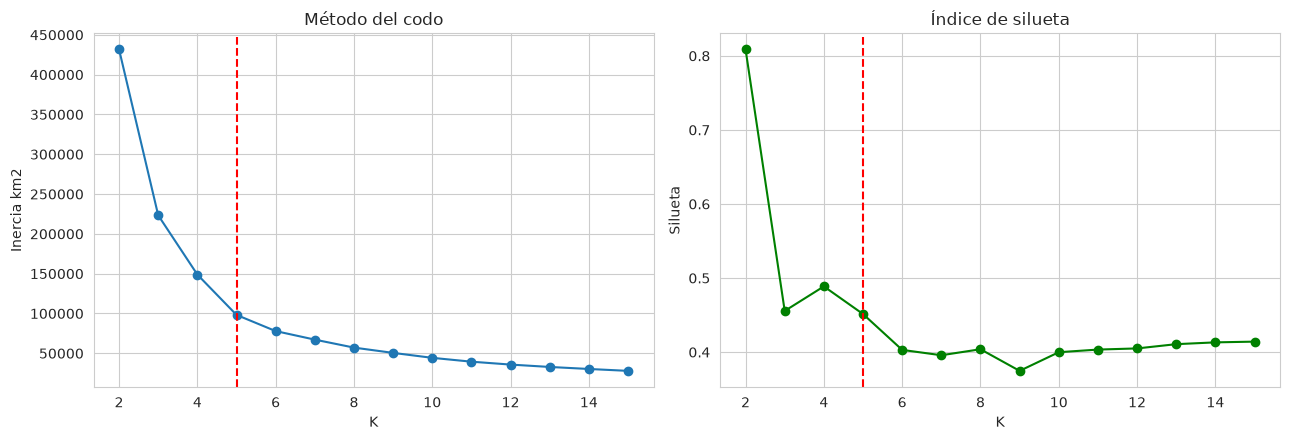

,K,inercia,silueta
0,2,431701.759,0.809
1,3,223297.979,0.456
2,4,148875.264,0.489
3,5,98203.193,0.451
4,6,77896.935,0.403
5,7,67169.946,0.396
6,8,57151.622,0.404
7,9,50509.147,0.375
8,10,44298.847,0.400
9,11,39467.606,0.403


In [31]:
# Codo y silueta para K entre 2 y 15
rango_k = range(2, 16)
inercias, siluetas = [], []

for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_geo)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_geo, km.labels_, sample_size=10000, random_state=SEMILLA))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(rango_k, inercias, marker="o")
ax[0].axvline(5, color="red", linestyle="--")
ax[0].set_title("Método del codo")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inercia km2")

ax[1].plot(rango_k, siluetas, marker="o", color="green")
ax[1].axvline(5, color="red", linestyle="--")
ax[1].set_title("Índice de silueta")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silueta")
plt.tight_layout()
plt.show()

pd.DataFrame({"K": list(rango_k), "inercia": inercias, "silueta": siluetas}).round(3)

Entrenamos K means con K igual a 5 y describimos cada cluster.

In [32]:
# Kmeans final
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=SEMILLA).fit(X_geo)
muestra["cluster_km"] = kmeans.labels_

perfil_km = muestra.groupby("cluster_km").agg(
    viajes=("id", "count"),
    lat=("pickup_latitude", "mean"),
    lon=("pickup_longitude", "mean"),
    distancia_km=("distancia_km", "mean"),
    duracion_min=("trip_duration", lambda x: x.mean() / 60),
    velocidad_kmh=("velocidad_kmh", "mean"),
    pct_fin_semana=("fin_de_semana", "mean"),
).round(3)
perfil_km

,viajes,lat,lon,distancia_km,duracion_min,velocidad_kmh,pct_fin_semana
cluster_km,,,,,,,
0,17492,40.755,-73.982,2.900,13.079,13.396,0.262
1,895,40.647,-73.785,17.698,41.873,28.135,0.282
2,1202,40.769,-73.873,8.700,27.289,21.186,0.245
3,11024,40.725,-73.996,3.255,13.728,14.139,0.348
4,9387,40.781,-73.962,2.757,11.827,14.773,0.267


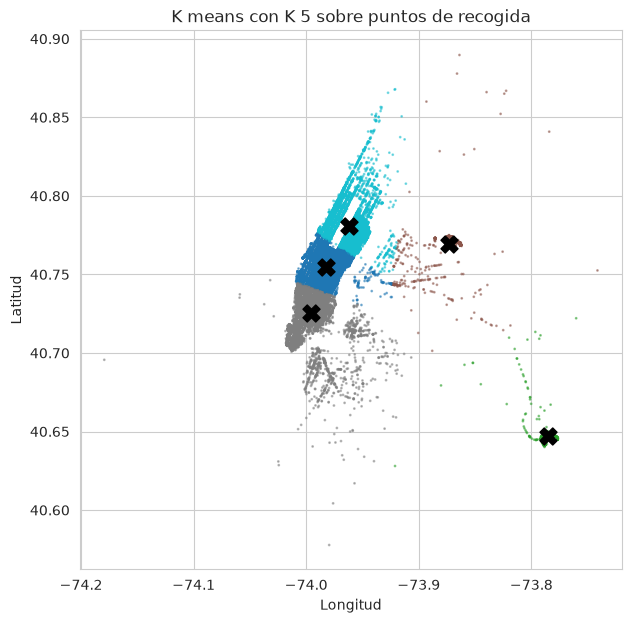

In [33]:
# Mapa de clusters Kmeans
plt.figure(figsize=(7, 7))
plt.scatter(muestra["pickup_longitude"], muestra["pickup_latitude"],
            c=muestra["cluster_km"], cmap="tab10", s=1, alpha=0.5)
centros = muestra.groupby("cluster_km")[["pickup_longitude", "pickup_latitude"]].mean()
plt.scatter(centros["pickup_longitude"], centros["pickup_latitude"],
            c="black", marker="X", s=150)
plt.title("K means con K 5 sobre puntos de recogida")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

Para DBSCAN fijamos min_samples en 50 y elegimos eps con la gráfica de k distancia, que muestra la distancia de cada punto a su vecino número 50.

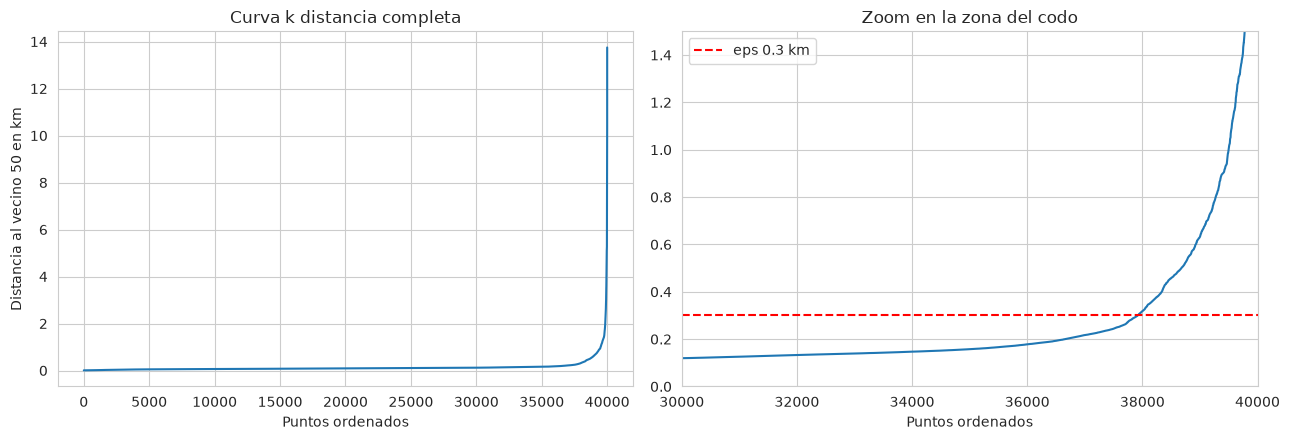

0.500   0.086
0.900   0.178
0.950   0.318
0.970   0.547
0.990   1.166
dtype: float64


In [34]:
# Grafica k distancia
MIN_SAMPLES = 50
vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_geo)
distancias, _ = vecinos.kneighbors(X_geo)
k_dist = np.sort(distancias[:, -1])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(k_dist)
ax[0].set_title("Curva k distancia completa")
ax[0].set_xlabel("Puntos ordenados")
ax[0].set_ylabel("Distancia al vecino 50 en km")

ax[1].plot(k_dist)
ax[1].axhline(0.3, color="red", linestyle="--", label="eps 0.3 km")
ax[1].set_ylim(0, 1.5)
ax[1].set_xlim(30000, 40000)
ax[1].set_title("Zoom en la zona del codo")
ax[1].set_xlabel("Puntos ordenados")
ax[1].legend()
plt.tight_layout()
plt.show()

print(pd.Series(k_dist).quantile([0.5, 0.9, 0.95, 0.97, 0.99]).round(3))

Como el codo abarca un rango, hacemos un análisis de sensibilidad de eps dentro de ese rango para elegir el valor final.

In [35]:
# Sensibilidad de eps
filas = []
for eps in [0.2, 0.3, 0.4, 0.5, 0.7]:
    etiquetas = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_geo)
    mascara = etiquetas != -1
    n_clusters = etiquetas.max() + 1
    sil = silhouette_score(X_geo[mascara], etiquetas[mascara],
                           sample_size=10000, random_state=SEMILLA) if n_clusters > 1 else np.nan
    filas.append({"eps_km": eps, "clusters": n_clusters,
                  "ruido_pct": (~mascara).mean() * 100, "silueta": sil})

pd.DataFrame(filas).round(3)

,eps_km,clusters,ruido_pct,silueta
0,0.200,7,5.625,0.101
1,0.300,3,4.415,0.687
2,0.400,5,3.293,0.353
3,0.500,6,2.410,0.374
4,0.700,7,1.298,0.209


Entrenamos DBSCAN con eps de 0.3 km y min_samples de 50, y describimos cada cluster y el ruido.

In [36]:
# DBSCAN final
EPS_FINAL = 0.3
dbscan = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES).fit(X_geo)
muestra["cluster_db"] = dbscan.labels_

perfil_db = muestra.groupby("cluster_db").agg(
    viajes=("id", "count"),
    lat=("pickup_latitude", "mean"),
    lon=("pickup_longitude", "mean"),
    distancia_km=("distancia_km", "mean"),
    duracion_min=("trip_duration", lambda x: x.mean() / 60),
    velocidad_kmh=("velocidad_kmh", "mean"),
    pct_fin_semana=("fin_de_semana", "mean"),
    pct_madrugada=("franja", lambda x: (x == "madrugada").mean()),
)
perfil_db["pct_viajes"] = perfil_db["viajes"] / len(muestra) * 100
perfil_db["pct_km"] = muestra.groupby("cluster_db")["distancia_km"].sum() / muestra["distancia_km"].sum() * 100
perfil_db.round(3)

,viajes,lat,lon,distancia_km,duracion_min,velocidad_kmh,pct_fin_semana,pct_madrugada,pct_viajes,pct_km
cluster_db,,,,,,,,,,
-1,1766,40.742,-73.944,4.286,14.554,17.792,0.356,0.234,4.415,5.454
0,36437,40.753,-73.982,2.935,12.937,13.819,0.285,0.112,91.092,77.040
1,842,40.645,-73.784,17.829,42.111,28.221,0.281,0.083,2.105,10.816
2,955,40.772,-73.868,9.723,30.250,21.781,0.215,0.053,2.388,6.690


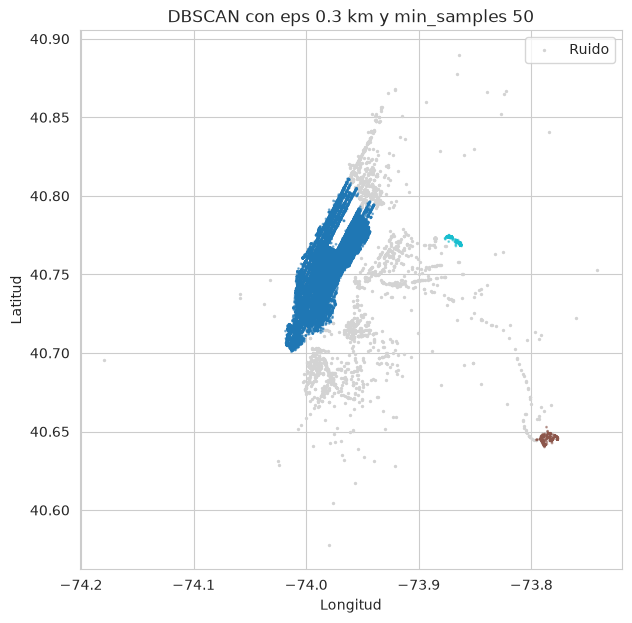

In [37]:
# Mapa DBSCAN con ruido en gris
plt.figure(figsize=(7, 7))
ruido = muestra["cluster_db"] == -1
plt.scatter(muestra.loc[ruido, "pickup_longitude"], muestra.loc[ruido, "pickup_latitude"],
            c="lightgray", s=2, label="Ruido")
plt.scatter(muestra.loc[~ruido, "pickup_longitude"], muestra.loc[~ruido, "pickup_latitude"],
            c=muestra.loc[~ruido, "cluster_db"], cmap="tab10", s=1, alpha=0.5)
plt.title("DBSCAN con eps 0.3 km y min_samples 50")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()

In [38]:
# Comparacion de metricas
mascara_db = muestra["cluster_db"] != -1
etq_db = muestra.loc[mascara_db, "cluster_db"]

comparacion = pd.DataFrame([
    {"metodo": "K means",
     "clusters": K_FINAL,
     "ruido_pct": 0.0,
     "silueta": silhouette_score(X_geo, kmeans.labels_, sample_size=10000, random_state=SEMILLA),
     "davies_bouldin": davies_bouldin_score(X_geo, kmeans.labels_),
     "calinski_harabasz": calinski_harabasz_score(X_geo, kmeans.labels_)},
    {"metodo": "DBSCAN",
     "clusters": etq_db.nunique(),
     "ruido_pct": (~mascara_db).mean() * 100,
     "silueta": silhouette_score(X_geo[mascara_db], etq_db, sample_size=10000, random_state=SEMILLA),
     "davies_bouldin": davies_bouldin_score(X_geo[mascara_db], etq_db),
     "calinski_harabasz": calinski_harabasz_score(X_geo[mascara_db], etq_db)},
]).round(3)
comparacion

,metodo,clusters,ruido_pct,silueta,davies_bouldin,calinski_harabasz
0,K means,5,0.000,0.451,0.560,69855.322
1,DBSCAN,3,4.415,0.687,0.228,32172.300


In [39]:
# Relacion entre ambos metodos
pd.crosstab(muestra["cluster_km"], muestra["cluster_db"],
            rownames=["K means"], colnames=["DBSCAN"])

DBSCAN,-1,0,1,2
K means,,,,
0,103,17389,0,0
1,53,0,842,0
2,247,0,0,955
3,777,10247,0,0
4,586,8801,0,0


Analizamos los viajes que DBSCAN marcó como ruido para proponer un tratamiento operativo.

In [40]:
# Perfil del ruido frente al nucleo
ruido_df = muestra[muestra["cluster_db"] == -1]
nucleo_df = muestra[muestra["cluster_db"] == 0]

print(f"Viajes de ruido: {len(ruido_df):,} que son {len(ruido_df) / len(muestra) * 100:.2f}%")
print(f"Ruido que cae en zona OTRA: {(ruido_df['zona_origen'] == 'OTRA').mean() * 100:.1f}%")
print(f"Madrugada ruido: {(ruido_df['franja'] == 'madrugada').mean() * 100:.1f}%")
print(f"Madrugada núcleo: {(nucleo_df['franja'] == 'madrugada').mean() * 100:.1f}%")
print(f"Fin de semana ruido: {ruido_df['fin_de_semana'].mean() * 100:.1f}%")
print(f"Fin de semana núcleo: {nucleo_df['fin_de_semana'].mean() * 100:.1f}%")

Viajes de ruido: 1,766 que son 4.42%
Ruido que cae en zona OTRA: 99.7%
Madrugada ruido: 23.4%
Madrugada núcleo: 11.2%
Fin de semana ruido: 35.6%
Fin de semana núcleo: 28.5%


### Hallazgos del clustering

- K means con K 5 divide la demanda en Midtown, Downtown, Upper Manhattan, LaGuardia y JFK. El codo indica K 5 y la silueta es 0,451.
- La silueta más alta la tiene K 2, con 0,809, pero es una partición trivial que solo separa JFK. No la elegimos porque no sirve para operar.
- DBSCAN con eps de 0,3 km y min_samples de 50 encuentra solo 3 zonas naturales: el núcleo de Manhattan, JFK y LaGuardia. Tiene mejores métricas: silueta de 0,687 contra 0,451 y Davies Bouldin de 0,228 contra 0,560.
- La diferencia clave es que DBSCAN muestra que Manhattan es una sola masa continua de demanda, mientras que K means la corta en tres con fronteras artificiales.
- Los aeropuertos son el 4,5% de los viajes pero el 17,5% de los kilómetros. Son pocos viajes pero muy valiosos.
- El ruido son 1.766 viajes, el 4,4%. Es demanda periférica fuera de las zonas frecuentes, con el doble de viajes de madrugada que el núcleo, 23,4% contra 11,2%.

Tratamiento operativo del ruido: no asignar conductores fijos a la periferia. Atender esos viajes bajo demanda desde el borde del núcleo más cercano, con una tarifa dinámica que compense el regreso sin pasajero, sobre todo en la madrugada.

## Fase 8: Mezclas gaussianas y EM (parte 1)

Modelamos cada viaje como generado por uno de varios perfiles latentes de movilidad. No observamos el perfil directamente, solo la distancia, la velocidad y la hora. Cada perfil es una distribución gaussiana y el modelo asigna a cada viaje una probabilidad de pertenecer a cada perfil.

In [41]:
# Hora operativa continua desde las 5 am
hora_decimal = muestra["pickup_datetime"].dt.hour + muestra["pickup_datetime"].dt.minute / 60
muestra["hora_op"] = (hora_decimal - 5) % 24

# Variables en escala logaritmica
muestra["log_dist"] = np.log(muestra["distancia_km"])
muestra["log_vel"] = np.log(muestra["velocidad_kmh"])

VARS_GMM = ["log_dist", "log_vel", "hora_op"]
escalador = StandardScaler().fit(muestra[VARS_GMM])
Z = escalador.transform(muestra[VARS_GMM])

print(muestra["hora"].value_counts().sort_index().head(8))
muestra[VARS_GMM].describe().T.round(3)

hora
0    1449
1    1019
2     756
3     562
4     404
5     411
6     874
7    1477
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
log_dist,40000.000,0.833,0.868,-2.975,0.223,0.753,1.363,3.829
log_vel,40000.000,2.543,0.521,0.012,2.216,2.554,2.885,4.224
hora_op,40000.000,11.653,5.737,0.000,6.900,11.983,16.283,23.983


Elegimos el número de perfiles K con el criterio de información bayesiano BIC, que premia el ajuste pero penaliza la cantidad de parámetros.

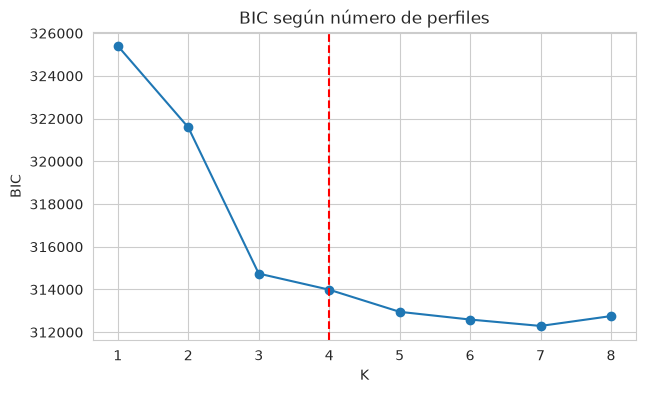

,K,BIC,mejora,mejora_pct
0,1,325402.000,NaN,NaN
1,2,321588.600,3813.400,1.170
2,3,314742.980,6845.620,2.130
3,4,313989.050,753.930,0.240
4,5,312953.150,1035.900,0.330
5,6,312591.460,361.690,0.120
6,7,312291.770,299.700,0.100
7,8,312753.840,-462.080,-0.150


In [42]:
# BIC para K entre 1 y 8
bics = []
for k in range(1, 9):
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          random_state=SEMILLA, n_init=3).fit(Z)
    bics.append(gmm.bic(Z))

tabla_bic = pd.DataFrame({"K": range(1, 9), "BIC": bics})
tabla_bic["mejora"] = -tabla_bic["BIC"].diff()
tabla_bic["mejora_pct"] = tabla_bic["mejora"] / tabla_bic["BIC"].shift() * 100

plt.figure(figsize=(7, 4))
plt.plot(tabla_bic["K"], tabla_bic["BIC"], marker="o")
plt.axvline(4, color="red", linestyle="--")
plt.title("BIC según número de perfiles")
plt.xlabel("K")
plt.ylabel("BIC")
plt.show()

tabla_bic.round(2)

Implementamos el algoritmo EM desde cero. Primero la densidad gaussiana en escala logarítmica y la inicialización de parámetros.

In [43]:
# Log densidad gaussiana multivariada
def log_gaussiana(X, mu, cov):
    d = X.shape[1]
    L = np.linalg.cholesky(cov)
    dif = np.linalg.solve(L, (X - mu).T)
    maha = np.sum(dif ** 2, axis=0)
    log_det = 2 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2 * np.pi) + log_det + maha)

# Inicializacion aleatoria o kmeans plus plus
def inicializar(X, K, metodo, semilla):
    n, d = X.shape
    rng = np.random.default_rng(semilla)
    if metodo == "aleatoria":
        mus = X[rng.choice(n, K, replace=False)]
    else:
        mus, _ = kmeans_plusplus(X, n_clusters=K, random_state=semilla)
    covs = np.array([np.cov(X.T) for _ in range(K)])
    pesos = np.full(K, 1 / K)
    return pesos, mus, covs

Definimos los dos pasos del algoritmo. En el paso E calculamos la responsabilidad de cada perfil sobre cada viaje. En el paso M actualizamos pesos, medias y covarianzas usando esas responsabilidades.

In [44]:
# Paso E
def paso_e(X, pesos, mus, covs):
    log_p = np.column_stack([np.log(pesos[k]) + log_gaussiana(X, mus[k], covs[k])
                             for k in range(len(pesos))])
    log_norm = logsumexp(log_p, axis=1)
    resp = np.exp(log_p - log_norm[:, None])
    return resp, log_norm.sum()

# Paso M
def paso_m(X, resp, reg=1e-6):
    n, d = X.shape
    Nk = resp.sum(axis=0)
    pesos = Nk / n
    mus = (resp.T @ X) / Nk[:, None]
    covs = []
    for k in range(resp.shape[1]):
        dif = X - mus[k]
        covs.append((resp[:, k, None] * dif).T @ dif / Nk[k] + reg * np.eye(d))
    return pesos, mus, np.array(covs)

Integramos los dos pasos en un ciclo que se repite hasta la convergencia. El criterio de parada es que la log verosimilitud promedio por viaje cambie menos de 0.000001 entre iteraciones, con un máximo de 500 iteraciones.

In [45]:
# Algoritmo EM completo
def em_gmm(X, K, metodo, semilla, tol=1e-6, max_iter=500):
    pesos, mus, covs = inicializar(X, K, metodo, semilla)
    historial = []
    for it in range(1, max_iter + 1):
        resp, ll = paso_e(X, pesos, mus, covs)
        historial.append(ll / len(X))
        if it > 1 and abs(historial[-1] - historial[-2]) < tol:
            break
        pesos, mus, covs = paso_m(X, resp)
    return {"pesos": pesos, "mus": mus, "covs": covs, "resp": resp,
            "historial": historial, "iteraciones": it}

Mostramos explícitamente la primera iteración con nuestros datos para ver cómo el paso E y el paso M transforman los parámetros.

In [46]:
# Iteracion 0 parametros iniciales
K_GMM = 4
p0, mu0, c0 = inicializar(Z, K_GMM, "kmeans++", SEMILLA)
print("Medias iniciales en unidades originales")
print(pd.DataFrame(escalador.inverse_transform(mu0), columns=VARS_GMM).round(3))

# Iteracion 1 paso E
resp1, ll1 = paso_e(Z, p0, mu0, c0)
print(f"\nLog verosimilitud promedio inicial: {ll1 / len(Z):.4f}")
print(f"Viajes efectivos por perfil: {resp1.sum(axis=0).round(1)}")

# Iteracion 1 paso M
p1, mu1, c1 = paso_m(Z, resp1)
print(f"\nPesos después del primer paso M: {p1.round(4)}")
print("Medias después del primer paso M")
print(pd.DataFrame(escalador.inverse_transform(mu1), columns=VARS_GMM).round(3))

Medias iniciales en unidades originales
   log_dist  log_vel  hora_op
0     1.952    2.678    7.950
1    -0.248    1.992   15.483
2     1.147    3.046   22.467
3     0.689    2.269    9.617

Log verosimilitud promedio inicial: -4.3841
Viajes efectivos por perfil: [ 9253.   8725.9  7277.4 14743.7]

Pesos después del primer paso M: [0.2313 0.2181 0.1819 0.3686]
Medias después del primer paso M
   log_dist  log_vel  hora_op
0     1.544    2.722    8.902
1     0.210    2.268   13.289
2     1.062    2.915   17.596
3     0.643    2.409    9.478


Corremos el EM completo con inicialización K means plus plus y verificamos que la log verosimilitud nunca disminuye, como garantiza la teoría.

Iteraciones hasta convergencia: 196
Log verosimilitud inicial: -4.3841
Log verosimilitud final: -3.9000
Nunca disminuye: True


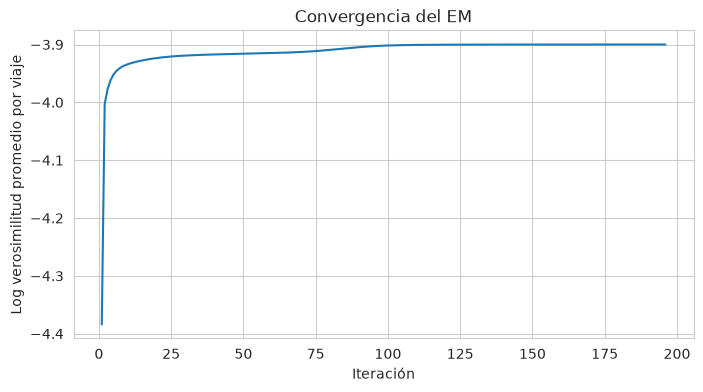

In [47]:
# EM completo semilla principal
modelo = em_gmm(Z, K_GMM, "kmeans++", SEMILLA)
hist = modelo["historial"]

print(f"Iteraciones hasta convergencia: {modelo['iteraciones']}")
print(f"Log verosimilitud inicial: {hist[0]:.4f}")
print(f"Log verosimilitud final: {hist[-1]:.4f}")
print(f"Nunca disminuye: {np.all(np.diff(hist) >= -1e-10)}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(hist) + 1), hist)
plt.title("Convergencia del EM")
plt.xlabel("Iteración")
plt.ylabel("Log verosimilitud promedio por viaje")
plt.show()

### Hallazgos de mezclas gaussianas parte 1

- Modelamos los viajes con tres variables: logaritmo de distancia, logaritmo de velocidad y hora operativa, que empieza a las 5 am para que la noche quede continua.
- El BIC mejora 2,13% al pasar de 2 a 3 perfiles, pero menos de 0,35% por cada perfil adicional después. Elegimos K 4 por interpretabilidad.
- En la primera iteración, el paso E repartió los viajes en 9.253, 8.726, 7.277 y 14.744 viajes efectivos, y el paso M actualizó los pesos de 0,25 a 0,231, 0,218, 0,182 y 0,369.
- El EM converge en 196 iteraciones con tolerancia de 0,000001. La log verosimilitud promedio sube de menos 4,384 a menos 3,900 y nunca disminuye, como garantiza la desigualdad de Jensen.

## Fase 8: Mezclas gaussianas y EM (parte 2)

El EM solo garantiza llegar a un máximo local, no al global. Para medir la sensibilidad a la inicialización corremos el algoritmo 10 veces con inicialización aleatoria y 10 con K means plus plus, cambiando la semilla.

In [48]:
# Comparacion de inicializaciones
filas = []
historiales = {}
for metodo in ["aleatoria", "kmeans++"]:
    for s in range(10):
        r = em_gmm(Z, K_GMM, metodo, s)
        historiales[(metodo, s)] = r["historial"]
        filas.append({
            "metodo": metodo,
            "semilla": s,
            "ll_inicial": r["historial"][0],
            "ll_final": r["historial"][-1],
            "iteraciones": r["iteraciones"],
        })

tabla_init = pd.DataFrame(filas)
tabla_init.round(4)

,metodo,semilla,ll_inicial,ll_final,iteraciones
0,aleatoria,0,-4.718,-3.914,261
1,aleatoria,1,-4.525,-3.915,113
2,aleatoria,2,-4.424,-3.900,144
3,aleatoria,3,-4.480,-3.900,271
4,aleatoria,4,-4.948,-3.900,161
5,aleatoria,5,-4.460,-3.900,305
6,aleatoria,6,-4.608,-3.913,121
7,aleatoria,7,-4.305,-3.900,191
8,aleatoria,8,-4.657,-3.915,299
9,aleatoria,9,-4.575,-3.900,149


In [49]:
# Resumen por metodo
LL_MEJOR = tabla_init["ll_final"].max()
tabla_init["llega_al_mejor"] = (LL_MEJOR - tabla_init["ll_final"]) < 1e-3

tabla_init.groupby("metodo").agg(
    ll_inicial_media=("ll_inicial", "mean"),
    ll_final_media=("ll_final", "mean"),
    ll_final_peor=("ll_final", "min"),
    iter_media=("iteraciones", "mean"),
    iter_min=("iteraciones", "min"),
    iter_max=("iteraciones", "max"),
    veces_mejor=("llega_al_mejor", "sum"),
).round(4)

,ll_inicial_media,ll_final_media,ll_final_peor,iter_media,iter_min,iter_max,veces_mejor
metodo,,,,,,,
aleatoria,-4.570,-3.906,-3.915,201.500,113,305,6
kmeans++,-4.468,-3.907,-3.915,213.000,91,375,5


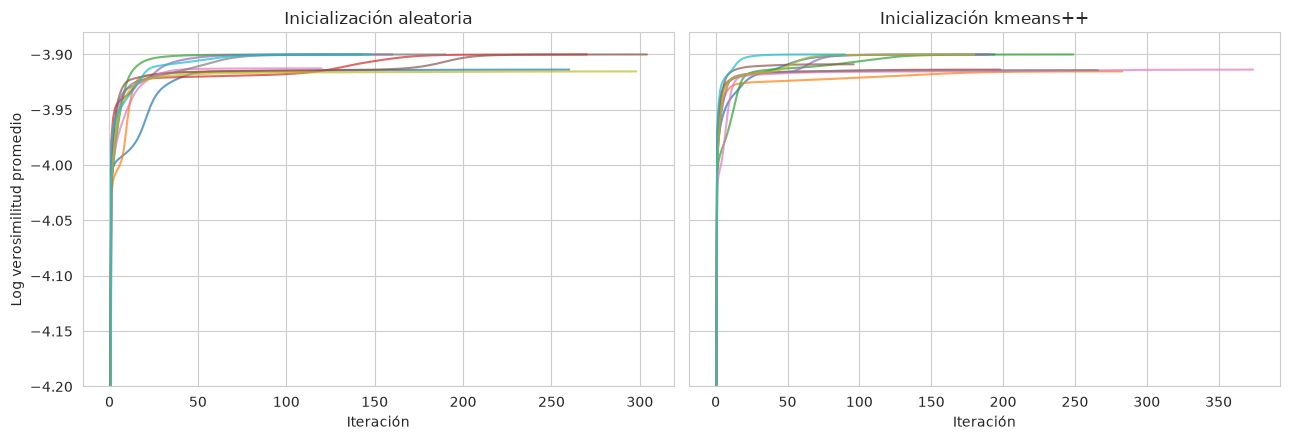

In [50]:
# Curvas de convergencia de las 20 corridas
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for i, metodo in enumerate(["aleatoria", "kmeans++"]):
    for s in range(10):
        ax[i].plot(historiales[(metodo, s)], alpha=0.7)
    ax[i].set_title(f"Inicialización {metodo}")
    ax[i].set_xlabel("Iteración")
    ax[i].set_ylim(-4.2, -3.88)
ax[0].set_ylabel("Log verosimilitud promedio")
plt.tight_layout()
plt.show()

Presentamos los parámetros finales del mejor modelo en unidades originales. La semilla principal con K means plus plus alcanzó la mejor log verosimilitud encontrada.

In [51]:
# Parametros finales en unidades originales
medias = pd.DataFrame(escalador.inverse_transform(modelo["mus"]), columns=VARS_GMM)
desv = pd.DataFrame([np.sqrt(np.diag(c)) * escalador.scale_ for c in modelo["covs"]],
                    columns=["sd_" + v for v in VARS_GMM])

parametros = pd.DataFrame({
    "peso": modelo["pesos"],
    "distancia_km": np.exp(medias["log_dist"]),
    "velocidad_kmh": np.exp(medias["log_vel"]),
    "hora_real": (medias["hora_op"] + 5) % 24,
    "sd_log_dist": desv["sd_log_dist"],
    "sd_log_vel": desv["sd_log_vel"],
    "sd_hora": desv["sd_hora_op"],
    "corr_dist_vel": [c[0, 1] / np.sqrt(c[0, 0] * c[1, 1]) for c in modelo["covs"]],
})
print(f"Log verosimilitud final: {modelo['historial'][-1]:.4f}")
print(f"Iteraciones: {modelo['iteraciones']}")
parametros.round(3)

Log verosimilitud final: -3.9000
Iteraciones: 196


,peso,distancia_km,velocidad_kmh,hora_real,sd_log_dist,sd_log_vel,sd_hora,corr_dist_vel
0,0.219,3.196,11.105,13.672,1.001,0.620,3.554,0.798
1,0.317,1.452,11.970,16.786,0.526,0.442,4.496,0.096
2,0.322,3.138,15.158,22.053,0.865,0.452,3.063,0.707
3,0.142,1.915,12.012,8.704,0.748,0.556,1.686,0.438


Asignamos cada viaje a su perfil más probable para describirlos y darles un nombre de negocio.

In [52]:
# Nombres de perfiles segun la hora media
NOMBRES_PERFIL = {3: "Commuter de mañana", 0: "Largo de mediodía",
                  1: "Corto de tarde", 2: "Nocturno de ocio"}

resp = modelo["resp"]
muestra["perfil"] = resp.argmax(axis=1)
muestra["resp_max"] = resp.max(axis=1)

perfiles = muestra.groupby("perfil").agg(
    viajes=("id", "count"),
    duracion_min=("trip_duration", lambda x: x.mean() / 60),
    pct_fin_semana=("fin_de_semana", "mean"),
    pct_aeropuerto=("cluster_db", lambda x: x.isin([1, 2]).mean()),
    resp_media=("resp_max", "mean"),
).rename(index=NOMBRES_PERFIL)
perfiles.round(3)

,viajes,duracion_min,pct_fin_semana,pct_aeropuerto,resp_media
perfil,,,,,
Largo de mediodía,8041,23.726,0.270,0.110,0.685
Corto de tarde,11188,7.361,0.320,0.002,0.690
Nocturno de ocio,13737,14.810,0.337,0.060,0.781
Commuter de mañana,7034,12.062,0.156,0.009,0.694


In [53]:
# Franjas dentro de cada perfil
pd.crosstab(muestra["perfil"].map(NOMBRES_PERFIL), muestra["franja"],
            normalize="index").round(2)

franja,madrugada,noche,pico_manana,pico_tarde,valle_dia
perfil,,,,,
Commuter de mañana,0.040,0.000,0.780,0.000,0.180
Corto de tarde,0.030,0.120,0.000,0.410,0.430
Largo de mediodía,0.010,0.020,0.070,0.190,0.700
Nocturno de ocio,0.280,0.530,0.000,0.190,0.000


Analizamos las responsabilidades. A diferencia de K means, la mezcla gaussiana no asigna cada viaje de forma rígida sino con una probabilidad de pertenencia a cada perfil.

Responsabilidad máxima media: 0.721
Viajes con perfil claro mayor a 0.9: 21.4%
Viajes ambiguos menor a 0.6: 29.4%


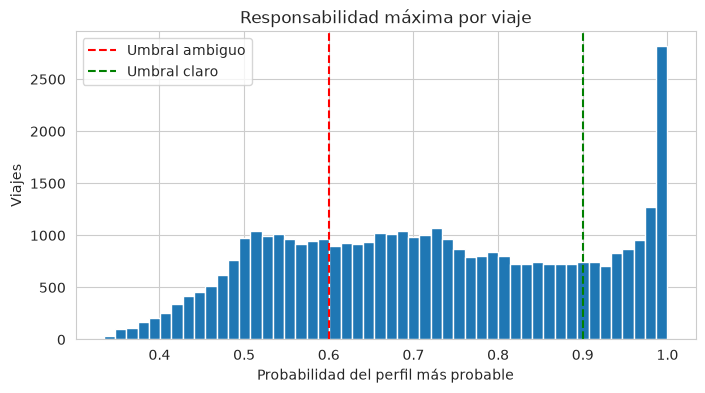

In [54]:
# Distribucion de la responsabilidad maxima
print(f"Responsabilidad máxima media: {muestra['resp_max'].mean():.3f}")
print(f"Viajes con perfil claro mayor a 0.9: {(muestra['resp_max'] > 0.9).mean() * 100:.1f}%")
print(f"Viajes ambiguos menor a 0.6: {(muestra['resp_max'] < 0.6).mean() * 100:.1f}%")

plt.figure(figsize=(8, 4))
plt.hist(muestra["resp_max"], bins=50)
plt.axvline(0.6, color="red", linestyle="--", label="Umbral ambiguo")
plt.axvline(0.9, color="green", linestyle="--", label="Umbral claro")
plt.title("Responsabilidad máxima por viaje")
plt.xlabel("Probabilidad del perfil más probable")
plt.ylabel("Viajes")
plt.legend()
plt.show()

In [55]:
# Ejemplos de viajes ambiguos
cols_resp = [NOMBRES_PERFIL[k] for k in range(K_GMM)]
ejemplos = pd.DataFrame(resp, columns=cols_resp)
ejemplos[["distancia_km", "velocidad_kmh", "hora"]] = muestra[["distancia_km", "velocidad_kmh", "hora"]].values
ejemplos.sort_values(cols_resp[0]).loc[muestra["resp_max"] < 0.45].head(5).round(3)

,Largo de mediodía,Corto de tarde,Nocturno de ocio,Commuter de mañana,distancia_km,velocidad_kmh,hora
15678,0.108,0.448,0.443,0.000,1.327,6.047,22.000
3187,0.110,0.442,0.448,0.000,2.553,12.783,18.000
32119,0.116,0.447,0.000,0.437,0.988,10.774,10.000
25613,0.118,0.440,0.442,0.000,1.221,7.067,19.000
7842,0.121,0.439,0.440,0.000,1.722,7.907,19.000


Validamos nuestra implementación comparándola con GaussianMixture de sklearn con la misma configuración.

In [56]:
# Validacion con sklearn
gmm_sk = GaussianMixture(n_components=K_GMM, covariance_type="full",
                         init_params="k-means++", random_state=SEMILLA,
                         tol=1e-6, max_iter=500).fit(Z)

print(f"Log verosimilitud nuestra: {modelo['historial'][-1]:.6f}")
print(f"Log verosimilitud sklearn: {gmm_sk.score(Z):.6f}")
print(f"Pesos nuestros ordenados: {np.sort(modelo['pesos']).round(4)}")
print(f"Pesos sklearn ordenados: {np.sort(gmm_sk.weights_).round(4)}")
print(f"Iteraciones sklearn: {gmm_sk.n_iter_}")

Log verosimilitud nuestra: -3.899986
Log verosimilitud sklearn: -3.899985
Pesos nuestros ordenados: [0.1419 0.2192 0.3169 0.3221]
Pesos sklearn ordenados: [0.1417 0.2192 0.317  0.3222]
Iteraciones sklearn: 422


### Hallazgos de mezclas gaussianas parte 2

- El EM tiene mínimos locales: las 20 corridas terminaron en 6 valores distintos de log verosimilitud, entre menos 3,9153 y menos 3,9000.
- K means plus plus arranca mejor, con log verosimilitud inicial de menos 4,468 contra menos 4,570, pero no termina mejor: alcanza el óptimo 5 de 10 veces contra 6 de 10 de la aleatoria. Como los perfiles se traslapan, separar las medias iniciales no garantiza el óptimo. Hay que correr varias inicializaciones.
- El modelo encontró 4 perfiles latentes:
  - Commuter de mañana: 14,2%, hacia las 8:42 am, 1,9 km. Es el más concentrado en el tiempo y solo 15,6% ocurre en fin de semana.
  - Largo de mediodía: 21,9%, hacia la 1:40 pm, 3,2 km y 11,1 km/h. Dura 23,7 minutos en promedio e incluye el 11% de los viajes a aeropuertos.
  - Corto de tarde: 31,7%, hacia las 4:47 pm, 1,45 km y 7,4 minutos. Es tráfico urbano puro.
  - Nocturno de ocio: 32,2%, hacia las 10 pm, 3,1 km y 15,2 km/h. Es el más rápido y el de más fin de semana, con 33,7%.
- Solo el 21,4% de los viajes tiene un perfil claro, con responsabilidad mayor a 0,9, y el 29,4% es ambiguo, menor a 0,6. La asignación suave aporta información que una partición dura perdería.
- La implementación propia coincide con sklearn en la log verosimilitud hasta la sexta cifra decimal.

## Fase 9: Integración y recomendaciones

Integramos los resultados de los tres bloques técnicos en una tabla resumen. Esta tabla es la base del documento de soporte y de las recomendaciones para UrbanMove.

In [57]:
# Tabla resumen Rol 1
resumen_rol1 = pd.DataFrame([
    {"metrica": "Entropía total origen", "valor": H_total, "unidad": "bits"},
    {"metrica": "Entropía madrugada", "valor": tabla_entropia.loc[tabla_entropia["franja"] == "madrugada", "entropia_bits"].values[0], "unidad": "bits"},
    {"metrica": "Entropía valle día", "valor": tabla_entropia.loc[tabla_entropia["franja"] == "valle_dia", "entropia_bits"].values[0], "unidad": "bits"},
    {"metrica": "KL laboral a fin de semana", "valor": kl(p_lab, p_fds), "unidad": "bits"},
    {"metrica": "KL fin de semana a laboral", "valor": kl(p_fds, p_lab), "unidad": "bits"},
    {"metrica": "KL madrugada a pico mañana", "valor": matriz_kl.loc["madrugada", "pico_manana"], "unidad": "bits"},
    {"metrica": "KL valle día a pico tarde", "valor": matriz_kl.loc["valle_dia", "pico_tarde"], "unidad": "bits"},
    {"metrica": "Información mutua hora destino", "valor": tabla_im.loc[tabla_im["variable"] == "hora", "info_mutua_bits"].values[0], "unidad": "bits"},
    {"metrica": "Información mutua origen destino", "valor": tabla_im.loc[tabla_im["variable"] == "zona_origen", "info_mutua_bits"].values[0], "unidad": "bits"},
])
resumen_rol1.round(4)

,metrica,valor,unidad
0,Entropía total origen,5.103,bits
1,Entropía madrugada,4.852,bits
2,Entropía valle día,5.100,bits
3,KL laboral a fin de semana,0.051,bits
4,KL fin de semana a laboral,0.055,bits
5,KL madrugada a pico mañana,0.408,bits
6,KL valle día a pico tarde,0.010,bits
7,Información mutua hora destino,0.098,bits
8,Información mutua origen destino,0.351,bits


In [58]:
# Tabla resumen Rol 2
comparacion

,metodo,clusters,ruido_pct,silueta,davies_bouldin,calinski_harabasz
0,K means,5,0.000,0.451,0.560,69855.322
1,DBSCAN,3,4.415,0.687,0.228,32172.300


In [59]:
# Tabla resumen Rol 3
print(f"Iteraciones hasta convergencia: {modelo['iteraciones']}")
print(f"Log verosimilitud final promedio: {modelo['historial'][-1]:.4f}")
parametros.rename(index=NOMBRES_PERFIL).round(3)

Iteraciones hasta convergencia: 196
Log verosimilitud final promedio: -3.9000


,peso,distancia_km,velocidad_kmh,hora_real,sd_log_dist,sd_log_vel,sd_hora,corr_dist_vel
Largo de mediodía,0.219,3.196,11.105,13.672,1.001,0.620,3.554,0.798
Corto de tarde,0.317,1.452,11.970,16.786,0.526,0.442,4.496,0.096
Nocturno de ocio,0.322,3.138,15.158,22.053,0.865,0.452,3.063,0.707
Commuter de mañana,0.142,1.915,12.012,8.704,0.748,0.556,1.686,0.438


In [60]:
# Nombres adicionales de zonas
NOMBRES.update({"Z25_30": "Penn Station", "Z27_34": "Upper East Side 2",
                "Z26_32": "Central Park Sur", "Z25_33": "Turtle Bay", "Z21_30": "Tribeca"})

# Cuatro zonas principales por franja
filas = []
for f in ORDEN_FRANJAS:
    top = muestra.loc[muestra["franja"] == f, "zona_origen"].value_counts(normalize=True).head(4)
    filas.append({
        "franja": f,
        "zonas_top": ", ".join(NOMBRES.get(z, z) for z in top.index),
        "pct_top4": top.sum() * 100,
    })
pd.DataFrame(filas).round(1)

,franja,zonas_top,pct_top4
0,madrugada,"Otras zonas, East Village, SoHo, West Village",29.400
1,pico_manana,"Otras zonas, Penn Station, Upper East Side 2, ...",24.500
2,valle_dia,"Midtown East, Otras zonas, Lenox Hill, Midtown...",22.300
3,pico_tarde,"Midtown East, Otras zonas, Murray Hill, Midtow...",22.500
4,noche,"Otras zonas, Midtown East, Murray Hill, Midtow...",24.500


In [61]:
# Demanda que cambia de zona en fin de semana
cambio_total = (p_fds - p_lab).abs().sum() / 2
print(f"Porcentaje de la demanda que cambia de zona en fin de semana: {cambio_total * 100:.1f}%")

# Zonas de vida nocturna en la noche
ZONAS_OCIO = ["Z22_31", "Z22_30", "Z23_29"]
noche = muestra["franja"].isin(["noche", "madrugada"])
ocio_fds = muestra.loc[noche & (muestra["fin_de_semana"] == 1), "zona_origen"].isin(ZONAS_OCIO).mean()
ocio_lab = muestra.loc[noche & (muestra["fin_de_semana"] == 0), "zona_origen"].isin(ZONAS_OCIO).mean()
print(f"East Village, SoHo y West Village en noche de fin de semana: {ocio_fds * 100:.1f}%")
print(f"East Village, SoHo y West Village en noche laboral: {ocio_lab * 100:.1f}%")

Porcentaje de la demanda que cambia de zona en fin de semana: 10.5%
East Village, SoHo y West Village en noche de fin de semana: 17.5%
East Village, SoHo y West Village en noche laboral: 10.8%


Evidencia para la recomendación de tarificación: peso de los aeropuertos y comportamiento del ruido frente al núcleo.

In [62]:
# Aeropuertos y ruido
es_aeropuerto = muestra["cluster_db"].isin([1, 2])
es_ruido = muestra["cluster_db"] == -1
es_nucleo = muestra["cluster_db"] == 0

print(f"Aeropuertos pct viajes: {es_aeropuerto.mean() * 100:.1f}%")
print(f"Aeropuertos pct km: {muestra.loc[es_aeropuerto, 'distancia_km'].sum() / muestra['distancia_km'].sum() * 100:.1f}%")
print(f"Distancia media ruido: {muestra.loc[es_ruido, 'distancia_km'].mean():.2f} km")
print(f"Distancia media núcleo: {muestra.loc[es_nucleo, 'distancia_km'].mean():.2f} km")

# Demanda por hora
demanda_hora = muestra["hora"].value_counts().sort_index()
print(f"Hora de mayor demanda: {demanda_hora.idxmax()} con {demanda_hora.max()} viajes")
print(f"Hora de menor demanda: {demanda_hora.idxmin()} con {demanda_hora.min()} viajes")
print(f"Razón pico valle: {demanda_hora.max() / demanda_hora.min():.1f} veces")

Aeropuertos pct viajes: 4.5%
Aeropuertos pct km: 17.5%
Distancia media ruido: 4.29 km
Distancia media núcleo: 2.93 km
Hora de mayor demanda: 18 con 2477 viajes
Hora de menor demanda: 4 con 404 viajes
Razón pico valle: 6.1 veces


Evidencia para la recomendación de flota flexible: porcentaje de viajes ambiguos por hora según la mezcla gaussiana.

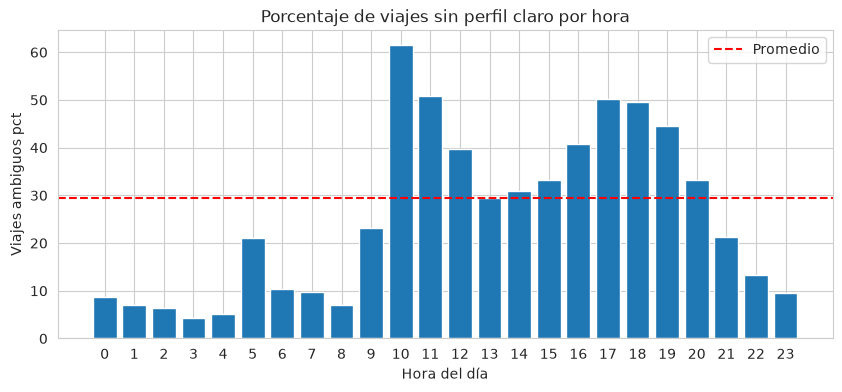

hora
0     8.800
1     7.100
2     6.500
3     4.300
4     5.200
5    21.200
6    10.300
7     9.700
8     7.000
9    23.100
10   61.500
11   50.800
12   39.800
13   29.400
14   31.000
15   33.200
16   40.800
17   50.300
18   49.600
19   44.600
20   33.300
21   21.200
22   13.300
23    9.500
Name: resp_max, dtype: float64

In [63]:
# Viajes ambiguos por hora
ambiguos_hora = muestra.groupby("hora")["resp_max"].apply(lambda x: (x < 0.6).mean() * 100)

plt.figure(figsize=(10, 4))
plt.bar(ambiguos_hora.index, ambiguos_hora.values)
plt.axhline(29.4, color="red", linestyle="--", label="Promedio")
plt.title("Porcentaje de viajes sin perfil claro por hora")
plt.xlabel("Hora del día")
plt.ylabel("Viajes ambiguos pct")
plt.xticks(range(24))
plt.legend()
plt.show()

ambiguos_hora.round(1)

### Recomendaciones para UrbanMove

1. Reposicionar la flota según la franja y el tipo de día.
   - Entre semana de 10 am a 8 pm usar un único plan de distribución centrado en Midtown East, Midtown West y Murray Hill. Valle día y pico tarde tienen una KL de solo 0,0096 bits, así que no se justifica planearlos por separado.
   - En fin de semana mover cerca del 10% de la flota desde Midtown East y el Upper East Side hacia East Village, SoHo, West Village y Chelsea. El 10,5% de la demanda cambia de zona y en la noche estas zonas pasan de 10,8% a 17,5% de las recogidas.
   - En la madrugada, la franja más predecible con 4,85 bits y 28,9 zonas efectivas, concentrar los conductores activos en East Village, SoHo y West Village, que suman el 18,5% de la demanda de madrugada.

2. Aplicar tarificación dinámica por zona y hora.
   - La demanda a las 6 pm es 6,1 veces la de las 4 am. La tarifa dinámica debe seguir esta curva para atraer conductores en las horas pico.
   - Los aeropuertos son el 4,5% de los viajes pero el 17,5% de los kilómetros. Recomendamos una tarifa fija a JFK y LaGuardia y una fila de conductores dedicada, sobre todo en la noche, cuando alcanzan el 5,4% de la demanda.

3. Tratar las zonas atípicas bajo demanda.
   - DBSCAN identificó 4,4% de viajes como ruido. El 99,7% ocurre fuera de las 42 zonas frecuentes, son 46% más largos que los del núcleo y el 23,4% ocurre de madrugada.
   - No asignar conductores fijos a la periferia. Atenderlos desde el borde del núcleo con un recargo que compense el regreso sin pasajero.

4. Mantener flota flexible en las horas de transición.
   - A las 10 am el 61% de los viajes no tiene un perfil claro, y a las 5 y 6 pm el 50%. En esas horas conviene tener conductores sin zona fija que el sistema pueda reasignar en tiempo real.
   - En la madrugada menos del 10% de los viajes es ambiguo, así que ahí sí funciona un plan fijo.

### Limitaciones y siguientes pasos

- Los datos son de 2016 y no incluyen tarifas ni disponibilidad de conductores, así que las recomendaciones de precio son de dirección y no de monto.
- La cuadrícula de 1 km es una decisión arbitraria. Un siguiente paso es repetir el análisis con los barrios oficiales de Nueva York.
- La mezcla gaussiana supone formas elípticas. Los perfiles podrían refinarse agregando el día de la semana o el destino.
- Trabajamos con una muestra de 40.000 viajes. Aunque la prueba KS confirmó que es representativa, el modelo final debería validarse sobre el dataset completo.